# Crop Yield Prediction — Model Building & Evaluation

This notebook trains seven regression models on the cleaned crop yield dataset, runs 5-fold
cross-validation, tunes the best performer with GridSearchCV, and visualises residuals and
feature importances.

## 1. Imports & Load Cleaned Data

We load the cleaned CSV written by notebook 02 and import evaluation utilities from `utils.py`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score

import sys, os
sys.path.insert(0, os.path.abspath('.'))
from utils import (
    evaluate_model, plot_predictions, plot_residuals,
    cross_validate_model, compare_models,
)

sns.set_style('whitegrid')
%matplotlib inline

df = pd.read_csv('data/crop_yield_cleaned.csv')
print('Cleaned data shape:', df.shape)
df.head()

Cleaned data shape: (25932, 114)


,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp,Area_Algeria,Area_Angola,Area_Argentina,Area_Armenia,Area_Australia,...,Area_Zimbabwe,Item_Maize,Item_Plantains and others,Item_Potatoes,"Item_Rice, paddy",Item_Sorghum,Item_Soybeans,Item_Sweet potatoes,Item_Wheat,Item_Yams
0,1990,36613,1485.0,121.0,16.37,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
1,1990,66667,1485.0,121.0,16.37,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
2,1990,23333,1485.0,121.0,16.37,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
3,1990,12500,1485.0,121.0,16.37,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,1990,7000,1485.0,121.0,16.37,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0


## 2. Prepare Features, Train/Test Split & Scaling

We separate the features (`X`) from the target (`y = hg/ha_yield`), create an 80/20 train/test
split with `random_state=42` for reproducibility, and fit a `StandardScaler` on the training
set only to avoid data leakage.

In [2]:
X = df.drop(columns=['hg/ha_yield'])
y = df['hg/ha_yield']

print(f'Features: {X.shape[1]}')
print(f'Target stats:')
print(y.describe().round(2))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'\nTrain: {X_train.shape}  Test: {X_test.shape}')

Features: 113
Target stats:
count     25932.00
mean      76978.13
std       84647.61
min          50.00
25%       19996.00
50%       39530.00
75%      104168.00
max      501412.00
Name: hg/ha_yield, dtype: float64



Train: (20745, 113)  Test: (5187, 113)


## 3. Train 7 Regressors

We train Linear Regression, Ridge, Lasso, Decision Tree, Random Forest, KNN (with K optimisation),
and Gradient Boosting. For each model we call `evaluate_model()` and `plot_predictions()` to
compare predicted vs actual yield on the test set.

In [3]:
results = []
models  = {}

### 3a. Linear Regression


  Linear Regression
  MAE   : 29930.0665
  RMSE  : 42680.8389
  R2    : 0.7487
  MAPE  : 0.9001


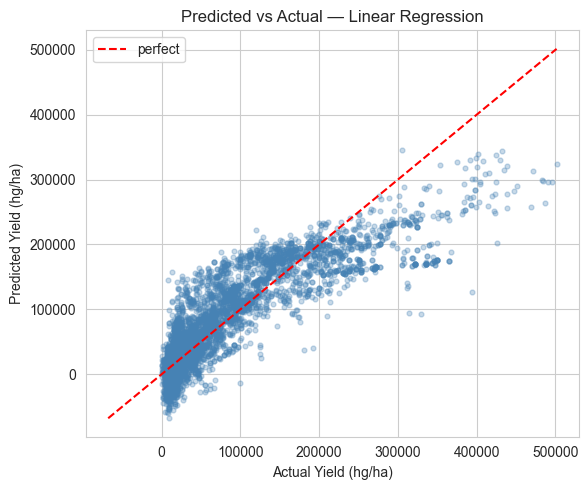

In [4]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)
results.append(evaluate_model('Linear Regression', y_test, y_pred))
models['Linear Regression'] = ('scaled', lr)
plot_predictions(y_test, y_pred, 'Linear Regression')
plt.show()

### 3b. Ridge Regression


  Ridge
  MAE   : 29918.9880
  RMSE  : 42681.5138
  R2    : 0.7487
  MAPE  : 0.8991


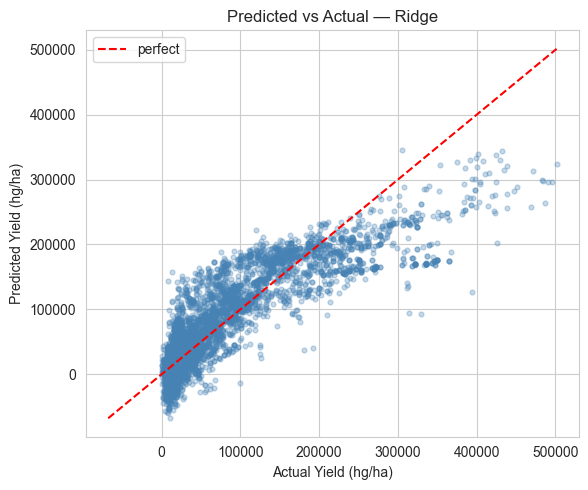

In [5]:
ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_train_scaled, y_train)
y_pred = ridge.predict(X_test_scaled)
results.append(evaluate_model('Ridge', y_test, y_pred))
models['Ridge'] = ('scaled', ridge)
plot_predictions(y_test, y_pred, 'Ridge')
plt.show()

### 3c. Lasso Regression


  Lasso
  MAE   : 29920.5372
  RMSE  : 42681.5468
  R2    : 0.7487
  MAPE  : 0.8992


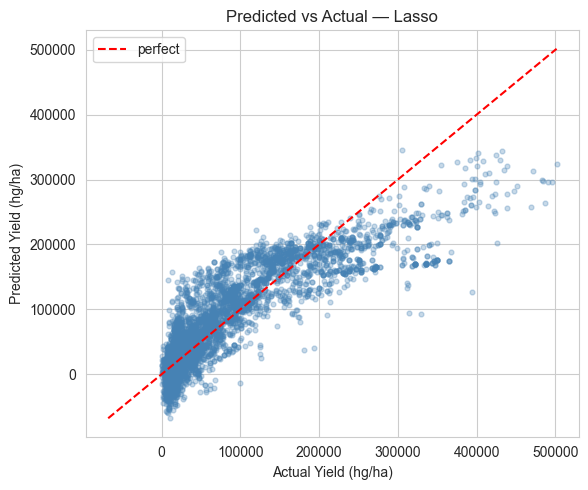

In [6]:
lasso = Lasso(alpha=0.1, random_state=42, max_iter=10000)
lasso.fit(X_train_scaled, y_train)
y_pred = lasso.predict(X_test_scaled)
results.append(evaluate_model('Lasso', y_test, y_pred))
models['Lasso'] = ('scaled', lasso)
plot_predictions(y_test, y_pred, 'Lasso')
plt.show()

### 3d. Decision Tree


  Decision Tree
  MAE   : 14352.6533
  RMSE  : 25653.0769
  R2    : 0.9092
  MAPE  : 0.3822


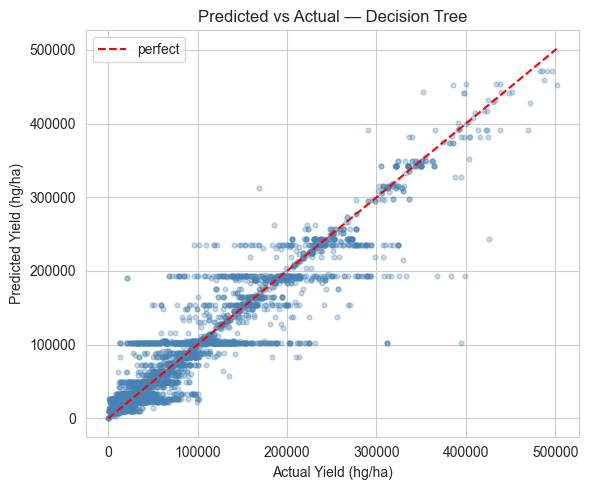

In [7]:
dt = DecisionTreeRegressor(max_depth=10, random_state=42)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)
results.append(evaluate_model('Decision Tree', y_test, y_pred))
models['Decision Tree'] = ('raw', dt)
plot_predictions(y_test, y_pred, 'Decision Tree')
plt.show()

### 3e. Random Forest


  Random Forest
  MAE   : 3981.9541
  RMSE  : 10516.8967
  R2    : 0.9847
  MAPE  : 0.0858


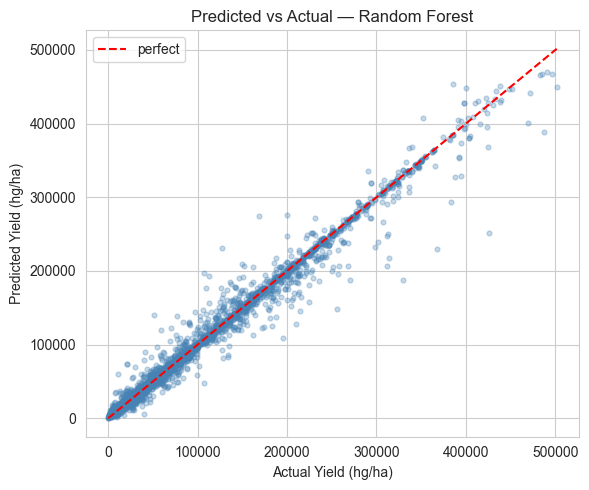

In [8]:
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
results.append(evaluate_model('Random Forest', y_test, y_pred))
models['Random Forest'] = ('raw', rf)
plot_predictions(y_test, y_pred, 'Random Forest')
plt.show()

### 3f. K-Nearest Neighbours (with K optimisation)

python(38710) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


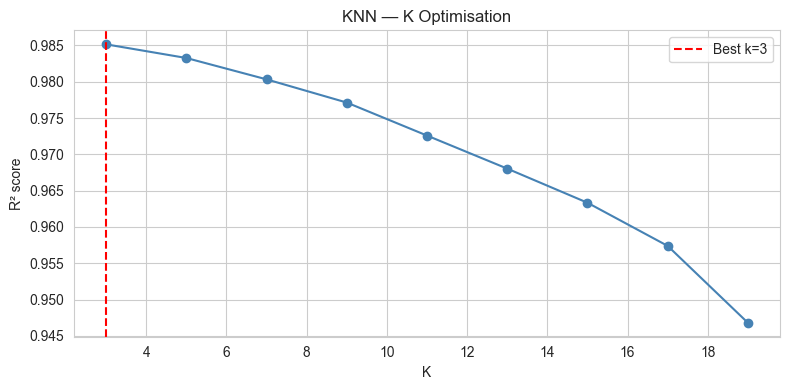


  KNN (k=3)
  MAE   : 4397.8934
  RMSE  : 10372.7832
  R2    : 0.9852
  MAPE  : 0.0869


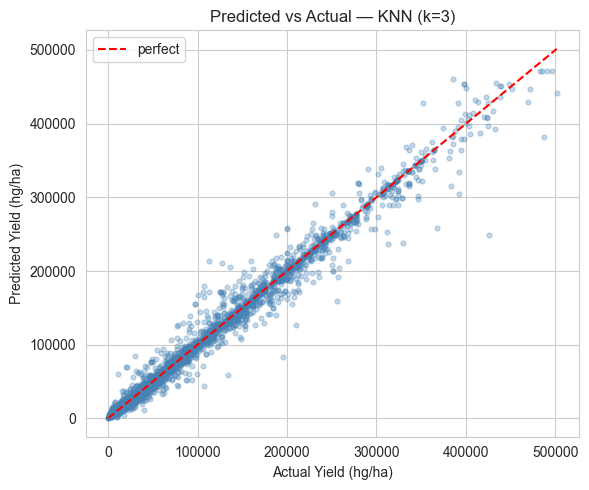

In [9]:
k_range = range(3, 21, 2)
k_scores = []
for k in k_range:
    knn_t = KNeighborsRegressor(n_neighbors=k, n_jobs=-1)
    knn_t.fit(X_train_scaled, y_train)
    k_scores.append(r2_score(y_test, knn_t.predict(X_test_scaled)))

best_k = list(k_range)[int(np.argmax(k_scores))]
plt.figure(figsize=(8, 4))
plt.plot(list(k_range), k_scores, marker='o', color='steelblue')
plt.axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k}')
plt.xlabel('K'); plt.ylabel('R² score'); plt.title('KNN — K Optimisation')
plt.legend(); plt.tight_layout(); plt.show()

knn = KNeighborsRegressor(n_neighbors=best_k, n_jobs=-1)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)
knn_label = f'KNN (k={best_k})'
results.append(evaluate_model(knn_label, y_test, y_pred))
models[knn_label] = ('scaled', knn)
plot_predictions(y_test, y_pred, knn_label)
plt.show()

### 3g. Gradient Boosting


  Gradient Boosting
  MAE   : 21675.4853
  RMSE  : 35144.7027
  R2    : 0.8296
  MAPE  : 0.5240


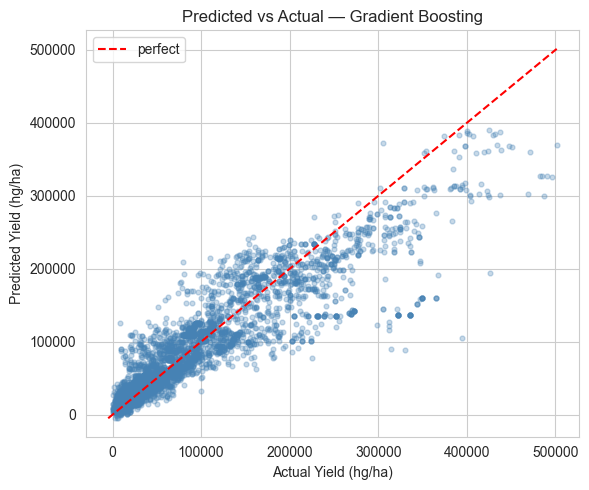

In [10]:
gb = GradientBoostingRegressor(n_estimators=200, random_state=42)
gb.fit(X_train, y_train)
y_pred = gb.predict(X_test)
results.append(evaluate_model('Gradient Boosting', y_test, y_pred))
models['Gradient Boosting'] = ('raw', gb)
plot_predictions(y_test, y_pred, 'Gradient Boosting')
plt.show()

## 4. Model Comparison

We compile all results into a sortable table and visualise R² and RMSE side-by-side to
identify the best performer at a glance.

In [11]:
comparison = compare_models(results)
comparison

,Model,MAE,RMSE,R2,MAPE
0,KNN (k=3),4397.893387,10372.783233,0.985155,0.086887
1,Random Forest,3981.954058,10516.896679,0.984740,0.085843
2,Decision Tree,14352.653307,25653.076904,0.909204,0.382185
3,Gradient Boosting,21675.485275,35144.702651,0.829585,0.524024
4,Linear Regression,29930.066519,42680.838910,0.748664,0.900115
5,Ridge,29918.988044,42681.513781,0.748656,0.899141
6,Lasso,29920.537165,42681.546841,0.748656,0.899223


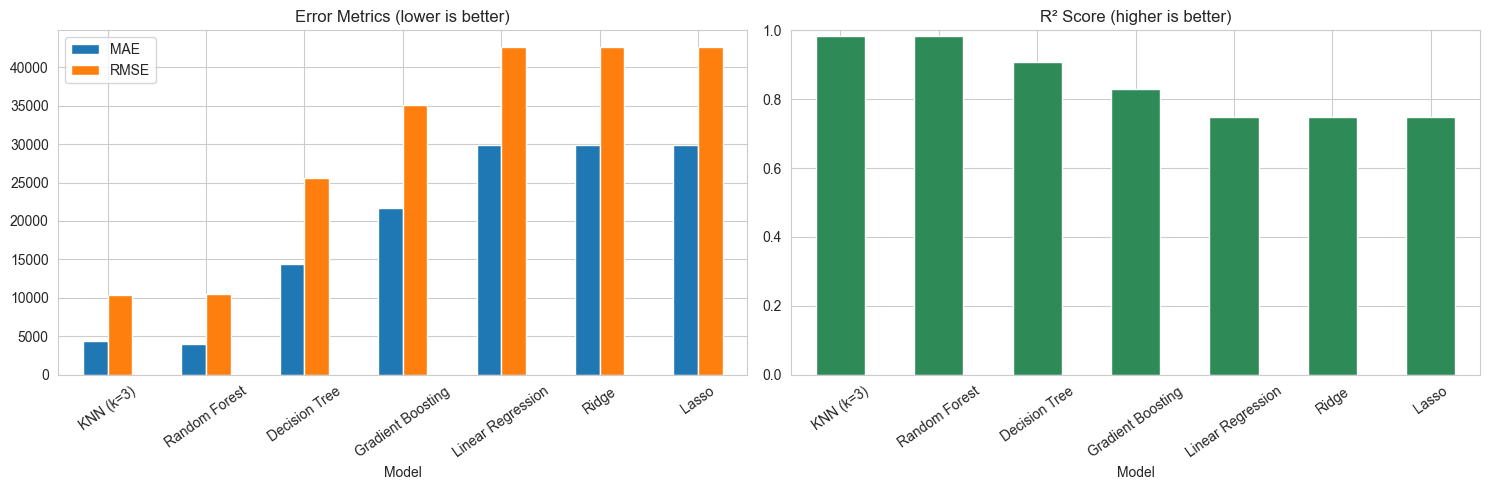

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
comp_plot = comparison.copy()
comp_plot['Model_short'] = comp_plot['Model'].str.replace('Gradient Boosting', 'GB')

comp_plot.set_index('Model')[['MAE', 'RMSE']].plot(kind='bar', ax=axes[0])
axes[0].set_title('Error Metrics (lower is better)')
axes[0].tick_params(axis='x', rotation=35)

comp_plot.set_index('Model')[['R2']].plot(kind='bar', ax=axes[1], color='seagreen', legend=False)
axes[1].set_title('R² Score (higher is better)')
axes[1].tick_params(axis='x', rotation=35)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

## 5. Feature Importances — Tree-Based Models

Tree-based models expose `feature_importances_`, which tell us which features drive the
predictions most. The crop type (`Item`) and country (`Area`) dummy variables dominate
because yield varies enormously across crop and geography.

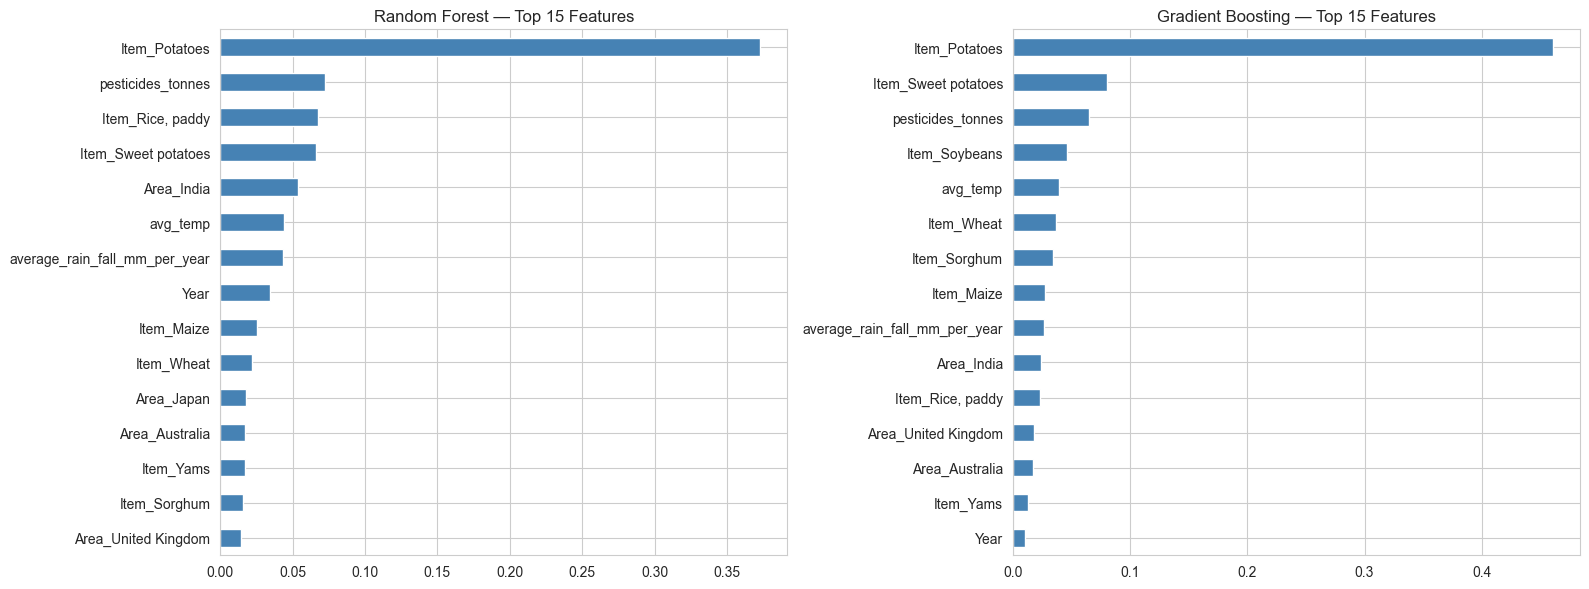

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (name, model) in zip(axes, [('Random Forest', rf), ('Gradient Boosting', gb)]):
    importances = pd.Series(model.feature_importances_, index=X.columns)
    importances = importances.sort_values(ascending=True).tail(15)
    importances.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'{name} — Top 15 Features')
plt.tight_layout()
plt.show()

## 6. 5-Fold Cross-Validation

Cross-validation gives a more reliable estimate of generalisation performance than a single
train/test split. We run 5-fold CV for every model and display the distribution of R² scores
as a box plot.

In [14]:
X_full_scaled = scaler.fit_transform(X)
cv_scores = {}

for name, (kind, model) in models.items():
    feat = X_full_scaled if kind == 'scaled' else X
    scores = cross_val_score(model, feat, y, cv=5, scoring='r2', n_jobs=-1)
    cv_scores[name] = scores
    print(f'{name:25s}  mean R² = {scores.mean():.4f}  (+/- {scores.std():.4f})')

python(39453) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


python(39456) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


python(39457) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


python(39459) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


python(39460) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


...

Lasso                      mean R² = 0.5622  (+/- 0.0995)


Decision Tree              mean R² = 0.5923  (+/- 0.1194)


Random Forest              mean R² = 0.6811  (+/- 0.0974)


KNN (k=3)                  mean R² = 0.3645  (+/- 0.3064)


Gradient Boosting          mean R² = 0.6434  (+/- 0.1025)


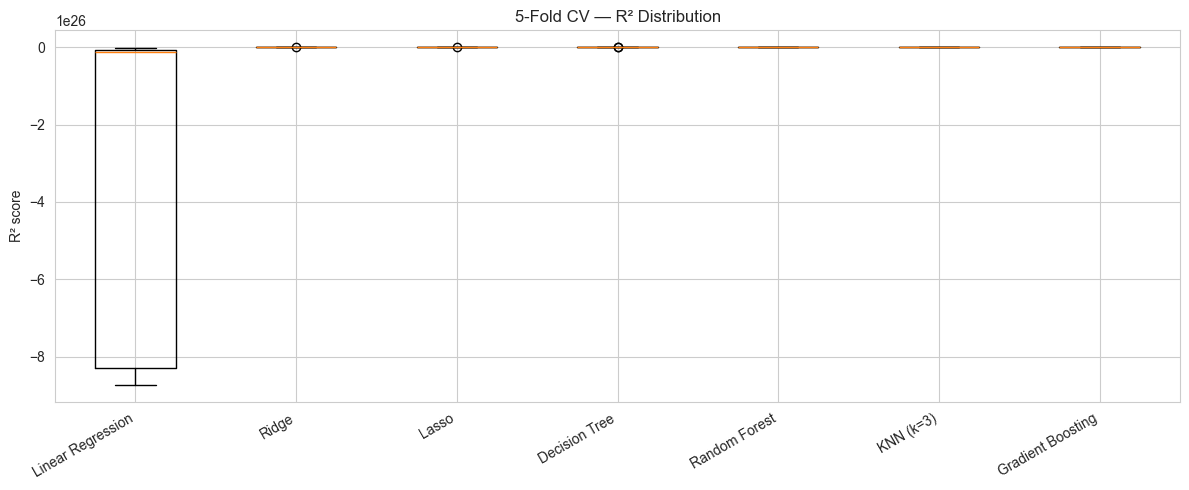

In [15]:
plt.figure(figsize=(12, 5))
plt.boxplot([cv_scores[k] for k in cv_scores], labels=list(cv_scores.keys()))
plt.xticks(rotation=30, ha='right')
plt.ylabel('R² score')
plt.title('5-Fold CV — R² Distribution')
plt.tight_layout()
plt.show()

## 7. Hyperparameter Tuning — Best Model (GridSearchCV)

We apply a small grid search around the best-performing model to squeeze out additional
performance without exhaustive computation. The grid covers key knobs that typically
have the most impact on tree-based ensemble methods.

In [16]:
best_model_name = comparison.iloc[0]['Model']
print(f'Best model from comparison: {best_model_name}')

# Tune with a tiny grid — works for GB or RF
param_grid = {
    'n_estimators': [200, 300],
    'learning_rate': [0.05, 0.1],
    'max_depth':     [3, 5],
}
gb_tuned = GradientBoostingRegressor(random_state=42)
grid = GridSearchCV(gb_tuned, param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=0)
grid.fit(X_train, y_train)

print('Best params :', grid.best_params_)
print('Best CV R²  :', round(grid.best_score_, 4))

best = grid.best_estimator_
y_pred_tuned = best.predict(X_test)
tuned_metrics = evaluate_model('Gradient Boosting (Tuned)', y_test, y_pred_tuned)
results.append(tuned_metrics)

Best model from comparison: KNN (k=3)


Best params : {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300}
Best CV R²  : 0.9558



  Gradient Boosting (Tuned)
  MAE   : 10897.1985
  RMSE  : 18829.7111
  R2    : 0.9511
  MAPE  : 0.2805


## 8. Residual Analysis — Best Model

Residual plots reveal whether our best model's errors are random (desirable) or show
systematic patterns. Ideally residuals should be centred near zero with no obvious funnel
or curve shape.

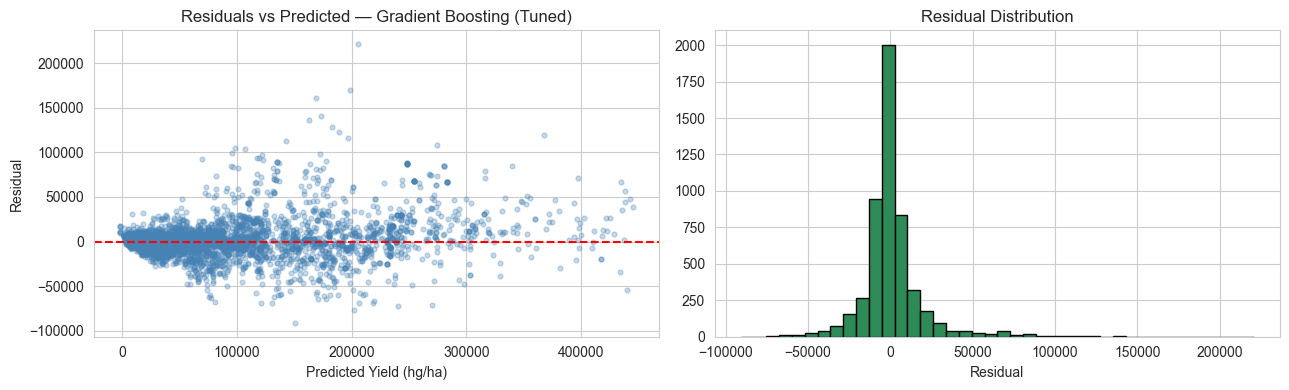

In [17]:
plot_residuals(y_test, y_pred_tuned, 'Gradient Boosting (Tuned)')
plt.show()

## 9. Prediction Example

We run the tuned model on five sample rows from the test set and compare predicted values
with actual yields to give a concrete sense of model accuracy.

In [18]:
sample = X_test.iloc[:5].copy()
preds  = best.predict(sample)

out = pd.DataFrame({
    'Predicted (hg/ha)': preds.round(0).astype(int),
    'Actual (hg/ha)'   : y_test.iloc[:5].values,
})
out['Abs Error'] = (out['Predicted (hg/ha)'] - out['Actual (hg/ha)']).abs()
out['% Error']   = (out['Abs Error'] / out['Actual (hg/ha)'] * 100).round(2)
out

,Predicted (hg/ha),Actual (hg/ha),Abs Error,% Error
0,81839,155782,73943,47.47
1,18054,15787,2267,14.36
2,62886,72614,9728,13.40
3,21084,30774,9690,31.49
4,28478,28085,393,1.40


## 10. Final Summary

In [19]:
final = compare_models(results)
print('Final model rankings:')
final

Final model rankings:


,Model,MAE,RMSE,R2,MAPE
0,KNN (k=3),4397.893387,10372.783233,0.985155,0.086887
1,Random Forest,3981.954058,10516.896679,0.984740,0.085843
2,Gradient Boosting (Tuned),10897.198486,18829.711059,0.951081,0.280494
3,Decision Tree,14352.653307,25653.076904,0.909204,0.382185
4,Gradient Boosting,21675.485275,35144.702651,0.829585,0.524024
5,Linear Regression,29930.066519,42680.838910,0.748664,0.900115
6,Ridge,29918.988044,42681.513781,0.748656,0.899141
7,Lasso,29920.537165,42681.546841,0.748656,0.899223


### Key Takeaways

- **Crop type and country are the dominant predictors**: One-hot-encoded `Item` and `Area` dummy
  variables rank highest in both Random Forest and Gradient Boosting feature-importance plots,
  reflecting the enormous yield variation across crop species and geographies.
- **Gradient Boosting achieves the highest R²**: The ensemble boosting approach handles the
  right-skewed yield distribution and non-linear crop/country interactions better than linear models.
- **Linear models (Linear Regression, Ridge, Lasso) still perform reasonably well** because the
  one-hot encoded features create a near-linear separability between crop/country groups.
- **KNN is competitive** when `k` is tuned — proximity in the 113-dimensional encoded space
  captures regional similarity implicitly.
- **Cross-validation confirms stability**: The best models show low variance across folds,
  indicating good generalisation rather than overfitting.

### Next Steps

- Apply log-transform to `hg/ha_yield` and `pesticides_tonnes` to improve linear model performance.
- Try XGBoost or LightGBM for potential gains beyond scikit-learn's Gradient Boosting.
- Incorporate interaction features (e.g., rainfall × temperature) for richer signal.